In [1]:
import emoji, re, string, time
import pandas as pd
import numpy as np
from scipy.stats import randint

#nlp
import nltk
from nltk.corpus import stopwords
import spacy

#dataviz
import matplotlib.pyplot as plt
import seaborn as sns

#features
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import linear_kernel
from sklearn import metrics
from sklearn.model_selection import train_test_split

#models
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import SGDClassifier
from sklearn.naive_bayes import BernoulliNB
from sklearn.naive_bayes import MultinomialNB
from sklearn.naive_bayes import ComplementNB
from sklearn.ensemble  import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold

get_ipython().run_line_magic('matplotlib', 'inline')
sns.set(style="darkgrid")


# cross_validation
from sklearn.model_selection import cross_validate

import os, psutil
os.environ["LOKY_MAX_CPU_COUNT"] = str(psutil.cpu_count(logical=False))

from sklearn.model_selection import train_test_split, learning_curve

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.utils import shuffle

In [2]:
filepath = '../../Datasets/Correto_whatsapp_rotulado_revisado.csv'

df = pd.read_csv(filepath)    

## visão geral

1. Visão Geral do Dataset:
- Número de Linhas: 3000
- Número de Colunas: 2

- Primeiros 5 registros:
                              text_content_anonymous  preconceito
0  Show :clapping_hands_light_skin_tone::clapping...            0
1  Mais uma vez o PT= Partido das Trevas apela ao...            1
2  Se não puder avise só para não quebrar a vigíl...            0
3              E a esquerda tenta impedir o trabalho            0
4  Deus perdoa porque eles Não sabem que fazem e ...            0

2. Informações Básicas:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 2 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   text_content_anonymous  2999 non-null   object
 1   preconceito             3000 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 47.0+ KB
None

3. Estatísticas Descritivas:
                                   text_content_anonymous  preconceito
count  

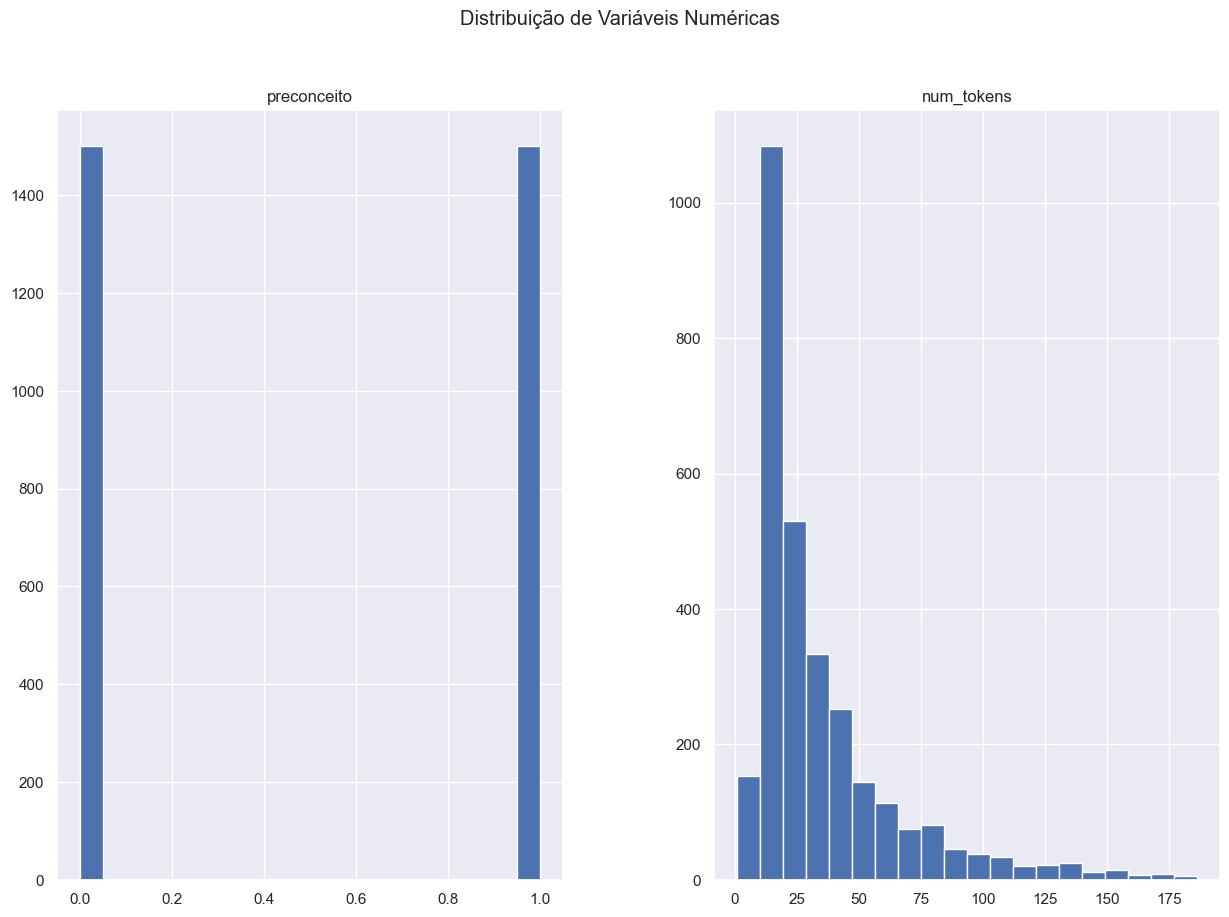


6. Distribuição de Variáveis Categóricas:

Coluna: text_content_anonymous
text_content_anonymous
Show :clapping_hands_light_skin_tone::clapping_hands_light_skin_tone::clapping_hands_light_skin_tone::clapping_hands_light_skin_tone::clapping_hands_light_skin_tone:   O Nordestino acordou                                                                                                                                                                                                    1
PESSOAL,  BÓRA DIVULGAR ESSE RETARDADO FAZENDO CAMPANHA PRA RISCAR CARROS COM ADESIVOS BOLSONARO!\nVAMOS ACABAR COM A CARREIRA DELE!                                                                                                                                                                                                                                                            1
Fui ameaçada de morte :woman_facepalming_medium-light_skin_tone:\nMandei até a localização pra vadia                              

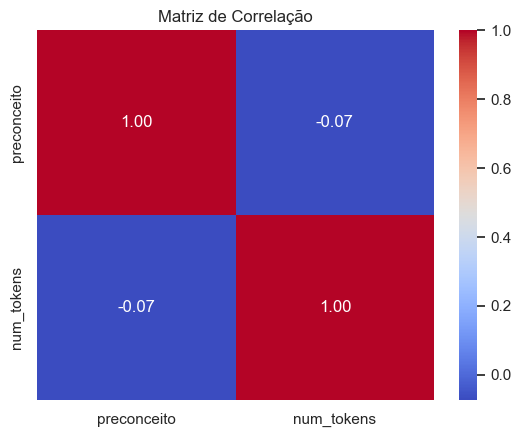


8. Outliers (Boxplots para Variáveis Numéricas):


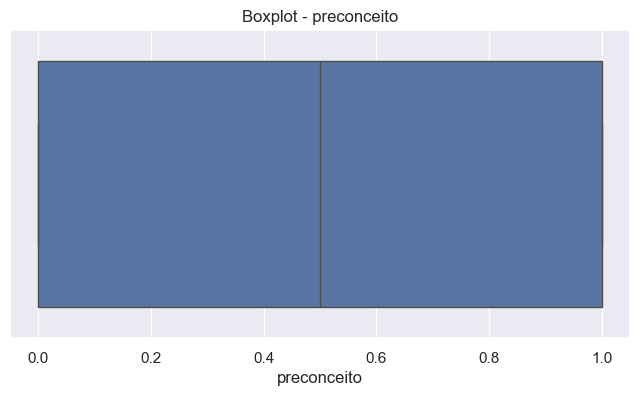

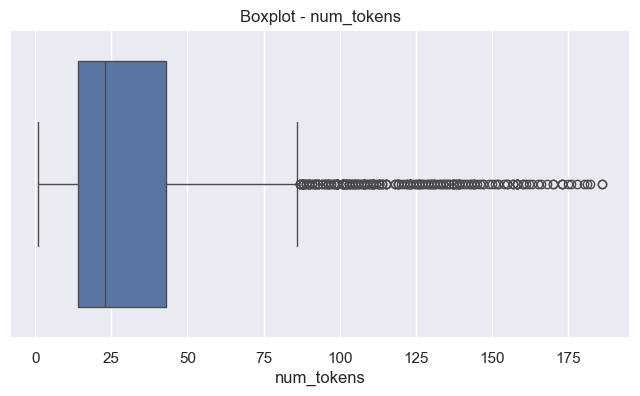


10. Dados Duplicados:
- Total de Registros Duplicados: 0


In [3]:


# 1. Visão Geral do Dataset
print("1. Visão Geral do Dataset:")
print(f"- Número de Linhas: {df.shape[0]}")
print(f"- Número de Colunas: {df.shape[1]}")
print("\n- Primeiros 5 registros:")
print(df.head())

# 2. Informações Básicas
print("\n2. Informações Básicas:")
print(df.info())

# 3. Estatísticas Descritivas
print("\n3. Estatísticas Descritivas:")
print(df.describe(include='all'))  # Inclui colunas categóricas e numéricas

mensagens_coluna = 'text_content_anonymous'  # Altere para o nome correto da coluna com as mensagens
df[mensagens_coluna] = df[mensagens_coluna].astype(str)

# Tokenizar mensagens (simples divisão por espaços)
df['num_tokens'] = df[mensagens_coluna].apply(lambda x: len(x.split()))

# 1. Quantidade de mensagens únicas
mensagens_unicas = df[mensagens_coluna].nunique()

# 2. Média e desvio-padrão do número de tokens
media_tokens = df['num_tokens'].mean()
desvio_tokens = df['num_tokens'].std()

print(media_tokens)
print(desvio_tokens)

# 3. Número mínimo de tokens
min_tokens = df['num_tokens'].min()

print(min_tokens)

# 4. Número máximo de tokens
max_tokens = df['num_tokens'].max()
print(max_tokens)

# 4. Checagem de Valores Nulos
print("\n4. Valores Nulos:")
print(df.isnull().sum())

# 5. Distribuição de Variáveis Numéricas
print("\n5. Distribuição de Variáveis Numéricas:")
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
df[numeric_cols].hist(bins=20, figsize=(15, 10))
plt.suptitle("Distribuição de Variáveis Numéricas")
plt.show()

# 6. Distribuição de Variáveis Categóricas
print("\n6. Distribuição de Variáveis Categóricas:")
categorical_cols = df.select_dtypes(include=['object', 'category']).columns
for col in categorical_cols:
    print(f"\nColuna: {col}")
    print(df[col].value_counts())

# 7. Matriz de Correlação
if not numeric_cols.empty:
    print("\n7. Matriz de Correlação:")
    corr_matrix = df[numeric_cols].corr()
    sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
    plt.title("Matriz de Correlação")
    plt.show()

# 8. Outliers (Boxplots para Numéricos)
print("\n8. Outliers (Boxplots para Variáveis Numéricas):")
for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot - {col}")
    plt.show()

# 9. Distribuição de Classes (se houver uma variável target)
if 'target' in df.columns:
    print("\n9. Distribuição de Classes (Target):")
    print(df['target'].value_counts(normalize=True))
    df['target'].value_counts().plot(kind='bar', title="Distribuição da Variável Target")
    plt.show()

# 10. Checagem de Dados Duplicados
print("\n10. Dados Duplicados:")
duplicates = df.duplicated().sum()
print(f"- Total de Registros Duplicados: {duplicates}")


# Funções que serão usadas para processamento de texto

In [3]:
unicode_emoji = {}
for key, value in emoji.EMOJI_DATA.items():
    try:
        unicode_emoji[key] = value['pt']
    except:
        pass

#emojis and punctuation
emojis_list = list(unicode_emoji)
punct = list(string.punctuation)
emojis_punct = emojis_list + punct

def processEmojisPunctuation(text, remove_punct = True):
    '''
    Put spaces between emojis. Removes punctuation.
    '''
    #get all unique chars
    chars = set(text)
    #for each unique char in text, do:
    for c in chars:
        #remove punctuation
        if remove_punct:
            if c in emojis_list:
                text = text.replace(c, ' ' + c + ' ')
            if c in punct:
                text = text.replace(c, ' ')

        #put spaces between punctuation
        else:
            if c in emojis_punct:
                text = text.replace(c, ' ' + c + ' ')          

    text = text.replace('  ', ' ')
    return text

#stop words removal
stop_words = list(stopwords.words('portuguese'))
new_stopwords = ['aí','pra','vão','vou','onde','lá','aqui',
                 'tá','pode','pois','so','deu','agora','todo',
                 'nao','ja','vc', 'bom', 'ai','kkk','kkkk','ta', 'voce', 'alguem', 'ne', 'pq',
                 'cara','to','mim','la','vcs','tbm', 'tudo']
stop_words = stop_words + new_stopwords
final_stop_words = []
for sw in stop_words:
    sw = ' '+ sw + ' '
    final_stop_words.append(sw)

def removeStopwords(text):
    for sw in final_stop_words:
        text = text.replace(sw,' ')
    text = text.replace('  ',' ')
    return text

#lemmatization
nlp = spacy.load('pt_core_news_sm')
def lemmatization(text):
    doc = nlp(text)
    for token in doc:
        if token.text != token.lemma_:
            text = text.replace(token.text, token.lemma_)
    return text


def domainUrl(text):
    '''
    Substitutes an URL in a text for the domain of this URL
    Input: an string
    Output: the string with the modified URL
    '''    
    if 'http' in text:
        re_url = '[^\s]*https*://[^\s]*'
        matches = re.findall(re_url, text, flags=re.IGNORECASE)
        for m in matches:
            domain = m.split('//')
            domain = domain[1].split('/')[0]
            text = re.sub(re_url, domain, text, 1)
        return text
    else:
        return text 

def preprocess(text):
    text = text.lower().strip()
    text = domainUrl(text)
    text = processEmojisPunctuation(text)
    text = removeStopwords(text)
    text = lemmatization(text)
    return text


# Definindo quais experimentos serão feitos

In [4]:
experiments = [
               'ml-tfidf-uni_gram',
               'ml-tfidf-uni_gram-processed',
               'ml-tfidf-unibi_gram',
               'ml-tfidf-unibi_gram-processed',
               'ml-tfidf-unibitri_gram',
               'ml-tfidf-unibitri_gram-processed',

            
               'ml-bow-uni_gram',
               'ml-bow-uni_gram-processed',
               'ml-bow-unibi_gram',
               'ml-bow-unibi_gram-processed',
               'ml-bow-unibitri_gram',
               'ml-bow-unibitri_gram-processed'
    
]

# Definindo a função getTestMetrics

In [5]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def getTestMetrics(y_test, y_pred, y_prob=None, full_metrics=True, print_charts=False):
    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    precision_neg = precision_score(y_test, y_pred, pos_label=0)
    recall = recall_score(y_test, y_pred)
    recall_neg = recall_score(y_test, y_pred, pos_label=0)
    f1 = f1_score(y_test, y_pred)
    f1_neg = 2 * (precision_neg * recall_neg) / (precision_neg + recall_neg)

    # Calcular o ROC AUC apenas se y_prob não for None
    if y_prob is not None:
        roc_auc = roc_auc_score(y_test, y_prob)
    else:
        roc_auc = None  # ou algum valor indicativo, como 0.0
    
    return (acc, precision, precision_neg, recall, recall_neg, f1, f1_neg, roc_auc)

In [6]:
# Função de pré-processamento
def preprocess_data(df, experiment):
    if 'processed' in experiment:
        print("Pré-processamento ativado.")
        pro_texts = [preprocess(t) for t in df['text_content_anonymous']]
    else:
        print("Sem pré-processamento.")
        pro_texts = [processEmojisPunctuation(t.lower(), remove_punct=False) for t in df['text_content_anonymous']]
    return pro_texts


In [7]:
# Configuração do vetorizador com base no experimento
def configure_vectorizer(experiment):
    if 'tfidf' in experiment:
        if 'uni_gram' in experiment:
            return TfidfVectorizer(ngram_range=(1, 1))
        elif 'unibi_gram' in experiment:
            return TfidfVectorizer(ngram_range=(1, 2))
        elif 'unibitri_gram' in experiment:
            return TfidfVectorizer(ngram_range=(1, 3))
        else:
            return TfidfVectorizer()
    elif 'bow' in experiment:
        if 'uni_gram' in experiment:
            return CountVectorizer(binary=True, ngram_range=(1, 1))
        elif 'unibi_gram' in experiment:
            return CountVectorizer(binary=True, ngram_range=(1, 2))
        elif 'unibitri_gram' in experiment:
            return CountVectorizer(binary=True, ngram_range=(1, 3))
        else:
            return CountVectorizer(binary=True)


## COMPLETO

In [ ]:



# Plotar a importância das features (limitado a 15 features mais importantes)
def plot_feature_importance(importances, feature_names, experiment, model_name, top_n=15):
    indices = np.argsort(importances)[::-1][:top_n]  # Selecionar as 15 mais importantes
    sorted_features = np.array(feature_names)[indices]
    sorted_importances = importances[indices]

    plt.figure(figsize=(10, 6))
    plt.bar(range(top_n), sorted_importances, align='center')
    plt.xticks(range(top_n), sorted_features, rotation=90, fontsize=8)
    plt.title(f"Top {top_n} Feature Importance ({experiment} - {model_name})")
    plt.xlabel("Features")
    plt.ylabel("Importance")
    plt.tight_layout()
    plt.show()

# Rodar para cada experimento
for experiment in experiments:
    start_time = time.time()

    try:
        print(f"Rodando experimento: {experiment}")

        # Removendo duplicatas e lidando com valores ausentes
        df = df.drop_duplicates(subset=['text_content_anonymous'])
        df['text_content_anonymous'] = df['text_content_anonymous'].fillna("")
        df['text_content_anonymous'] = df['text_content_anonymous'].astype(str)

        # Processar textos dependendo do experimento
        pro_texts = preprocess_data(df, experiment)

        # Configuração de vetorizador
        vectorizer = configure_vectorizer(experiment)
        X_texts = vectorizer.fit_transform(pro_texts)
        vocab_size_texts = X_texts.shape[1]

        # Printar o número de features do vetorizador
        print(f"[{experiment}] Número de features do vetorizador: {vocab_size_texts}")

        X_final = X_texts
        y = df['preconceito']

        # Dividir os dados em treino e teste
        X_train, X_test, y_train, y_test = train_test_split(
            X_final, y, test_size=0.2, stratify=y, random_state=42
        )

        # Definir os modelos a serem usados
        models = [
            LogisticRegression(), BernoulliNB(), MultinomialNB(), LinearSVC(dual=False),
            KNeighborsClassifier(), SGDClassifier(), RandomForestClassifier(),
            GradientBoostingClassifier(n_estimators=200),
            MLPClassifier(batch_size=64, max_iter=50, early_stopping=True, verbose=False)
        ]

        feature_names = list(vectorizer.get_feature_names_out()) 

        resultados = []

        # Avaliando os modelos
        for model in models:
            resultado_linha = dict()
            resultado_linha['model'] = model.__class__.__name__
            resultado_linha['vocab_size_text'] = vocab_size_texts

            # Medir o tempo de execução
            model_start_time = time.time()
            metodos_scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
            cv_results = cross_validate(model, X_train, y_train, cv=5, scoring=metodos_scoring, return_train_score=True)
            model_end_time = time.time()
            execution_time = model_end_time - model_start_time

            resultado_linha['execution_time'] = execution_time

            # Salvar as métricas
            for scoring in metodos_scoring:
                scores = cv_results[f'test_{scoring}']
                resultado_linha[f'{scoring}_avg'] = scores.mean()
                resultado_linha[f'{scoring}_std'] = scores.std()

            resultados.append(resultado_linha)

            # Plotar a importância das features (se aplicável)
            if hasattr(model, 'feature_importances_'):
                importances = model.feature_importances_
                plot_feature_importance(importances, feature_names, experiment, model.__class__.__name__)
            elif hasattr(model, 'coef_'):
                importances = np.abs(model.coef_[0])  # Para modelos lineares
                plot_feature_importance(importances, feature_names, experiment, model.__class__.__name__)

            # Printar informações durante a execução
            print(f"Model: {model.__class__.__name__} | Experiment: {experiment}")
            print(f"Vocab Size (text): {vocab_size_texts}")
            print(f"Execution Time: {execution_time:.2f} seconds")
            print("-" * 50)

        # Tempo total do experimento
        experiment_time = time.time() - start_time
        print(f"Tempo total do experimento '{experiment}': {experiment_time:.2f} seconds")

        # Criar um DataFrame com os resultados
        df_metrics = pd.DataFrame(resultados)
        df_metrics['total_time'] = experiment_time  # Adicionando o tempo total

        # Salvar os resultados em um arquivo CSV
        path_to_save = f"./resultados/01_09_25_Whatsapp_resultados_{experiment}.csv"
        df_metrics.to_csv(path_to_save, index=False)

        print(f"Resultados salvos em: {path_to_save}")

    except Exception as e:
        print(f"[{experiment}] Erro ao executar o experimento: {e}")


Rodando experimento: ml-tfidf-uni_gram
Sem pré-processamento.
[ml-tfidf-uni_gram] Número de features do vetorizador: 12540
Model: LogisticRegression | Experiment: ml-tfidf-uni_gram
Vocab Size (text): 12540
Execution Time: 0.42 seconds
--------------------------------------------------
Model: BernoulliNB | Experiment: ml-tfidf-uni_gram
Vocab Size (text): 12540
Execution Time: 0.10 seconds
--------------------------------------------------
Model: MultinomialNB | Experiment: ml-tfidf-uni_gram
Vocab Size (text): 12540
Execution Time: 0.09 seconds
--------------------------------------------------
Model: LinearSVC | Experiment: ml-tfidf-uni_gram
Vocab Size (text): 12540
Execution Time: 0.22 seconds
--------------------------------------------------
Model: KNeighborsClassifier | Experiment: ml-tfidf-uni_gram
Vocab Size (text): 12540
Execution Time: 4.24 seconds
--------------------------------------------------
Model: SGDClassifier | Experiment: ml-tfidf-uni_gram
Vocab Size (text): 12540
Exe

Rodando experimento: ml-tfidf-unibi_gram
Sem pré-processamento.
[ml-tfidf-unibi_gram] Número de features do vetorizador: 72560

 Resultados - Gradient Boosting (TF-IDF bigram)
Acurácia:  0.892
Precisão:  0.976
Revocação: 0.803
F1:        0.881
ROC AUC:   0.951


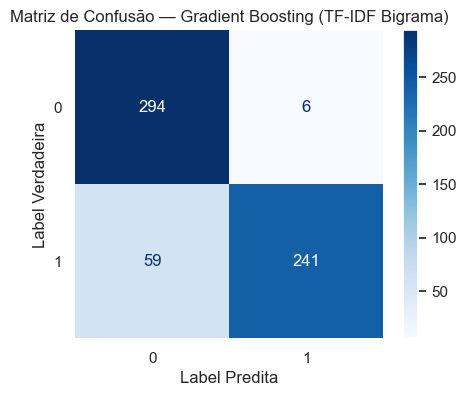

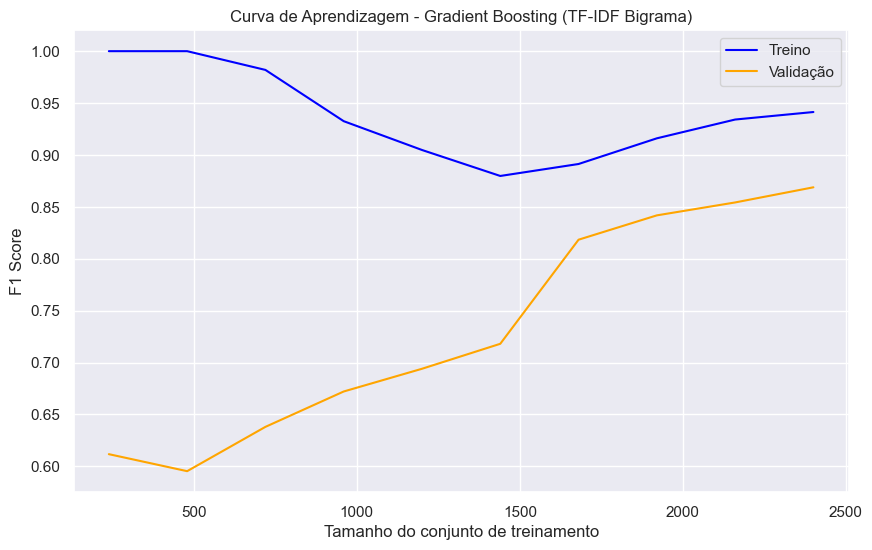

In [ ]:

# === Escolher experimento ===
experiment = 'ml-tfidf-unibi_gram'
print(f"Rodando experimento: {experiment}")

# --- Pré-processar textos ---
df = df.drop_duplicates(subset=['text_content_anonymous'])
df['text_content_anonymous'] = df['text_content_anonymous'].fillna("").astype(str)
pro_texts = preprocess_data(df, experiment)

# --- Vetorizador TF-IDF unigram, bigram ---
vectorizer = configure_vectorizer(experiment)
X_texts = vectorizer.fit_transform(pro_texts)
vocab_size_texts = X_texts.shape[1]

print(f"[{experiment}] Número de features do vetorizador: {vocab_size_texts}")

X_final = X_texts
y = df['preconceito']

# --- Divisão treino/teste ---
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y, test_size=0.2, stratify=y, random_state=42
)

# --- Modelo Gradient Boosting ---
model = GradientBoostingClassifier(n_estimators=200)

# --- Treinamento ---
model.fit(X_train, y_train)

# --- Predições ---
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# --- Métricas ---
acc, prec_pos, prec_neg, rec_pos, rec_neg, f1_pos, f1_neg, roc_auc = getTestMetrics(
    y_test, y_pred, y_prob
)

print("\n Resultados - Gradient Boosting (TF-IDF bigram)")
print(f"Acurácia:  {acc:.3f}")
print(f"Precisão:  {prec_pos:.3f}")
print(f"Revocação: {rec_pos:.3f}")
print(f"F1:        {f1_pos:.3f}")
print(f"ROC AUC:   {roc_auc:.3f}")


# --- Matriz de confusão ---
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["0", "1"])
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(cmap="Blues", values_format="d", ax=ax)

# Renomear eixos
ax.set_xlabel("Label Predita")
ax.set_ylabel("Label Verdadeira")

for spine in ax.spines.values():
    spine.set_visible(False)  # Remove bordas externas

ax.grid(False)                # Remove linhas de grade
plt.title("Matriz de Confusão — Gradient Boosting (TF-IDF Bigrama)")

plt.savefig("./resultados/matriz_confusao_gradient_boosting_tfidf_unibi_whatsapp.png", dpi=300, bbox_inches="tight")
plt.show()

# === Curva de Aprendizado ===

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
train_sizes, train_scores, val_scores = learning_curve(
    model, X_final, y,
    cv=cv, scoring="f1", n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10)
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.title("Curva de Aprendizagem - Gradient Boosting (TF-IDF Bigrama)")
plt.plot(train_sizes, train_mean, color="blue", label="Treino")
plt.plot(train_sizes, val_mean, color="orange", label="Validação")
plt.xlabel("Tamanho do conjunto de treinamento")
plt.ylabel("F1 Score")
plt.legend(loc="best")
plt.grid(True)
plt.show()



### InglÊs

Rodando experimento: ml-tfidf-unibi_gram
Sem pré-processamento.
[ml-tfidf-unibi_gram] Número de features do vetorizador: 72560

 Resultados - Gradient Boosting (TF-IDF bigram)
Acurácia:  0.892
Precisão:  0.976
Revocação: 0.803
F1:        0.881
ROC AUC:   0.950


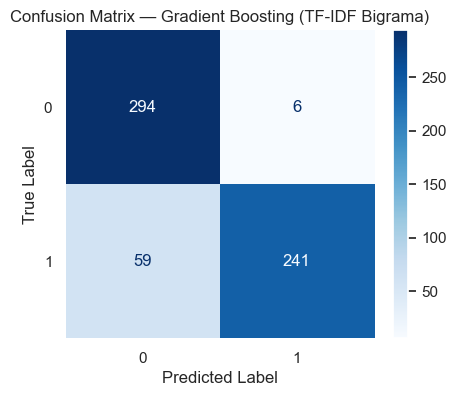

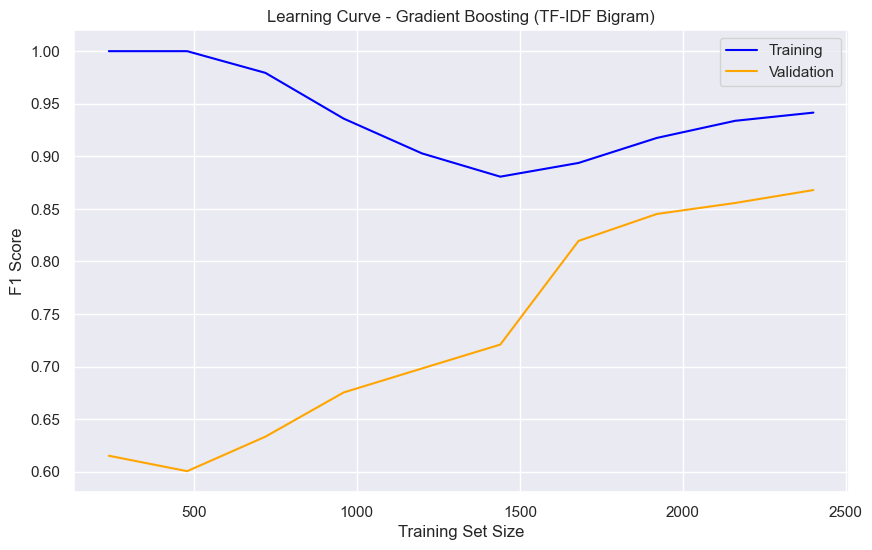

In [8]:

# === Escolher experimento ===
experiment = 'ml-tfidf-unibi_gram'
print(f"Rodando experimento: {experiment}")

# --- Pré-processar textos ---
df = df.drop_duplicates(subset=['text_content_anonymous'])
df['text_content_anonymous'] = df['text_content_anonymous'].fillna("").astype(str)
pro_texts = preprocess_data(df, experiment)

# --- Vetorizador TF-IDF unigram, bigram ---
vectorizer = configure_vectorizer(experiment)
X_texts = vectorizer.fit_transform(pro_texts)
vocab_size_texts = X_texts.shape[1]

print(f"[{experiment}] Número de features do vetorizador: {vocab_size_texts}")

X_final = X_texts
y = df['preconceito']

# --- Divisão treino/teste ---
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y, test_size=0.2, stratify=y, random_state=42
)

# --- Modelo Gradient Boosting ---
model = GradientBoostingClassifier(n_estimators=200)

# --- Treinamento ---
model.fit(X_train, y_train)

# --- Predições ---
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# --- Métricas ---
acc, prec_pos, prec_neg, rec_pos, rec_neg, f1_pos, f1_neg, roc_auc = getTestMetrics(
    y_test, y_pred, y_prob
)

print("\n Resultados - Gradient Boosting (TF-IDF bigram)")
print(f"Acurácia:  {acc:.3f}")
print(f"Precisão:  {prec_pos:.3f}")
print(f"Revocação: {rec_pos:.3f}")
print(f"F1:        {f1_pos:.3f}")
print(f"ROC AUC:   {roc_auc:.3f}")


# --- Matriz de confusão ---
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["0", "1"])
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(cmap="Blues", values_format="d", ax=ax)

# Renomear eixos
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")

for spine in ax.spines.values():
    spine.set_visible(False)  # Remove bordas externas

ax.grid(False)                # Remove linhas de grade
plt.title("Confusion Matrix — Gradient Boosting (TF-IDF Bigrama)")

plt.savefig("./resultados/matriz_confusao_gradient_boosting_tfidf_unibi_whatsapp_ingles.png", dpi=300, bbox_inches="tight")
plt.show()

# === Curva de Aprendizado ===

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
train_sizes, train_scores, val_scores = learning_curve(
    model, X_final, y,
    cv=cv, scoring="f1", n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10)
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.title("Learning Curve - Gradient Boosting (TF-IDF Bigram)")
plt.plot(train_sizes, train_mean, color="blue", label="Training")
plt.plot(train_sizes, val_mean, color="orange", label="Validation")
plt.xlabel("Training Set Size")
plt.ylabel("F1 Score")
plt.legend(loc="best")
plt.grid(True)
plt.show()



# FOLD 5

In [9]:
# BOW

# === Escolher experimento ===
experiment = 'ml-bow-uni_gram'
print(f"Rodando experimento: {experiment}")

# --- Pré-processar textos ---
df = df.drop_duplicates(subset=['text_content_anonymous'])
df['text_content_anonymous'] = df['text_content_anonymous'].fillna("").astype(str)
pro_texts = preprocess_data(df, experiment)

# --- Vetorizador TF-IDF unigram, bigram ---
vectorizer = configure_vectorizer(experiment)
X_texts = vectorizer.fit_transform(pro_texts)
vocab_size_texts = X_texts.shape[1]

print(f"[{experiment}] Número de features do vetorizador: {vocab_size_texts}")

X_final = X_texts
y = df['preconceito']

results = []

# =====================================================
# 5 EXECUÇÕES
# =====================================================

for run, seed in enumerate(range(42, 47), start=1):

    # --- Divisão treino/teste ---
    X_train, X_test, y_train, y_test = train_test_split(
        X_final,
        y,
        test_size=0.2,
        stratify=y,
        random_state=seed
    )

    model = LogisticRegression(random_state=42)

    # --- Treinamento ---
    model.fit(X_train, y_train)

    # --- Predições ---
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # --- Métricas ---
    acc, prec_pos, prec_neg, rec_pos, rec_neg, f1_pos, f1_neg, roc_auc = getTestMetrics(
        y_test, y_pred, y_prob
    )

    # --- Salvar resultados ---
    results.append({
        'run': run,
        'accuracy': acc,
        'precision': prec_pos,
        'recall': rec_pos,
        'f1': f1_pos,
        'roc_auc': roc_auc
    })

    print(f"\nExecução {run}")
    print(f"F1: {f1_pos:.3f}")

# =====================================================
# DATAFRAME FINAL
# =====================================================

results_df = pd.DataFrame(results)

print("\nResultados:")
print(results_df)

# =====================================================
# MÉDIA E DESVIO
# =====================================================

print("\nResumo:")
print(results_df.describe().loc[['mean', 'std']])

# =====================================================
# SALVAR CSV
# =====================================================

results_df.to_csv(
    f'{experiment}_wpp_fold5_resultados.csv',
    index=False
)

Rodando experimento: ml-bow-uni_gram
Sem pré-processamento.
[ml-bow-uni_gram] Número de features do vetorizador: 12539

Execução 1
F1: 0.878

Execução 2
F1: 0.870

Execução 3
F1: 0.882

Execução 4
F1: 0.846

Execução 5
F1: 0.869

Resultados:
   run  accuracy  precision    recall        f1   roc_auc
0    1  0.881667   0.904594  0.853333  0.878216  0.940467
1    2  0.871667   0.883162  0.856667  0.869712  0.940022
2    3  0.883333   0.893836  0.870000  0.881757  0.943878
3    4  0.850000   0.867133  0.826667  0.846416  0.933800
4    5  0.871667   0.888502  0.850000  0.868825  0.934856

Resumo:
           run  accuracy  precision    recall        f1   roc_auc
mean  3.000000  0.871667   0.887445  0.851333  0.868985  0.938604
std   1.581139  0.013281   0.013847  0.015741  0.013768  0.004196


In [10]:
# TF-IDF

# === Escolher experimento ===
experiment = 'ml-tfidf-bi_gram'
print(f"Rodando experimento: {experiment}")

# --- Pré-processar textos ---
df = df.drop_duplicates(subset=['text_content_anonymous'])
df['text_content_anonymous'] = df['text_content_anonymous'].fillna("").astype(str)
pro_texts = preprocess_data(df, experiment)

# --- Vetorizador TF-IDF unigram, bigram ---
vectorizer = configure_vectorizer(experiment)
X_texts = vectorizer.fit_transform(pro_texts)
vocab_size_texts = X_texts.shape[1]

print(f"[{experiment}] Número de features do vetorizador: {vocab_size_texts}")

X_final = X_texts
y = df['preconceito']

results = []

# =====================================================
# 5 EXECUÇÕES
# =====================================================

for run, seed in enumerate(range(42, 47), start=1):

    # --- Divisão treino/teste ---
    X_train, X_test, y_train, y_test = train_test_split(
        X_final,
        y,
        test_size=0.2,
        stratify=y,
        random_state=seed
    )

    model = GradientBoostingClassifier(n_estimators=200)

    # --- Treinamento ---
    model.fit(X_train, y_train)

    # --- Predições ---
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # --- Métricas ---
    acc, prec_pos, prec_neg, rec_pos, rec_neg, f1_pos, f1_neg, roc_auc = getTestMetrics(
        y_test, y_pred, y_prob
    )

    # --- Salvar resultados ---
    results.append({
        'run': run,
        'accuracy': acc,
        'precision': prec_pos,
        'recall': rec_pos,
        'f1': f1_pos,
        'roc_auc': roc_auc
    })

    print(f"\nExecução {run}")
    print(f"F1: {f1_pos:.3f}")

# =====================================================
# DATAFRAME FINAL
# =====================================================

results_df = pd.DataFrame(results)

print("\nResultados:")
print(results_df)

# =====================================================
# MÉDIA E DESVIO
# =====================================================

print("\nResumo:")
print(results_df.describe().loc[['mean', 'std']])

# =====================================================
# SALVAR CSV
# =====================================================

results_df.to_csv(
    f'{experiment}_wpp_fold5_resultados.csv',
    index=False
)

Rodando experimento: ml-tfidf-bi_gram
Sem pré-processamento.
[ml-tfidf-bi_gram] Número de features do vetorizador: 12539

Execução 1
F1: 0.876

Execução 2
F1: 0.870

Execução 3
F1: 0.870

Execução 4
F1: 0.866

Execução 5
F1: 0.843

Resultados:
   run  accuracy  precision    recall        f1   roc_auc
0    1  0.886667   0.967742  0.800000  0.875912  0.952872
1    2  0.880000   0.948819  0.803333  0.870036  0.948650
2    3  0.880000   0.948819  0.803333  0.870036  0.938267
3    4  0.875000   0.931034  0.810000  0.866310  0.946250
4    5  0.860000   0.957627  0.753333  0.843284  0.945444

Resumo:
           run  accuracy  precision    recall        f1   roc_auc
mean  3.000000  0.876333   0.950808  0.794000  0.865116  0.946297
std   1.581139  0.010028   0.013529  0.023022  0.012679  0.005338
